In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

In [2]:
# We will create:
# - 170 points belonging to two dense clusters
# - 30 scattered points acting as noise/outliers
# - Total = 200 points
#
# We use 2 dimensions so that we can visualize the data easily.

np.random.seed(42)

# Create two dense clusters
X_clusters, _ = make_blobs(
    n_samples=170,
    centers=[
        (-2.5, -1.5),
        (2.5, 2.0)
    ],
    cluster_std=[
        0.55,
        0.65
    ],
    random_state=42
)

# Create 30 scattered points
X_noise = np.random.uniform(
    low=[-6, -5],
    high=[6, 6],
    size=(30, 2)
)

# Combine clusters + noise
X = np.vstack([X_clusters, X_noise])

print("Dataset shape:", X.shape)

Dataset shape: (200, 2)


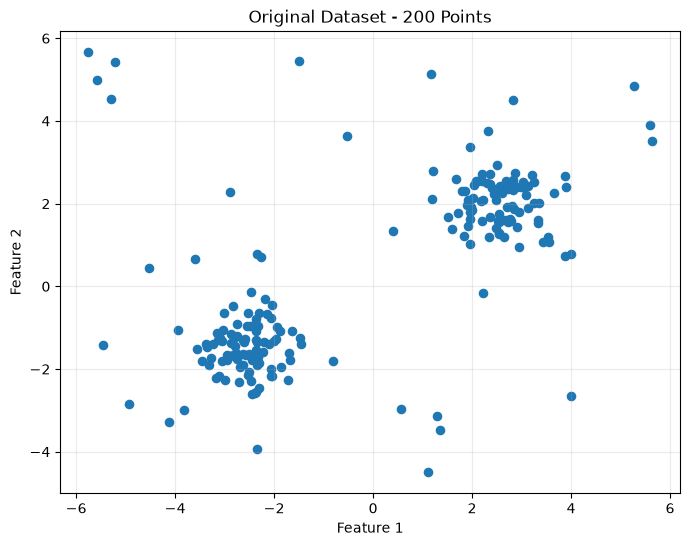

In [3]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    s=35
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Original Dataset - 200 Points")

plt.grid(alpha=0.25)

plt.show()

# Feature Scaling

In [5]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (200, 2)


In [6]:
X_scaled

array([[-0.56338045, -1.21238055],
       [ 1.10692464,  0.28497298],
       [-0.82103282, -1.36205529],
       [-0.78146981, -1.03669643],
       [ 1.05744841,  0.75002288],
       [ 0.89919701,  0.62312983],
       [ 0.89563405,  0.98764743],
       [ 0.62756014,  0.48879178],
       [ 1.35757628,  0.89432295],
       [-0.99795634, -0.98236991],
       [-0.84610696, -0.45432047],
       [ 0.99726012,  0.39580103],
       [ 0.96514133,  0.56751279],
       [-1.01975711, -0.45807928],
       [ 0.96105455,  0.42683738],
       [-0.90641857, -1.05916506],
       [ 0.75580663,  0.67495804],
       [ 0.47717919,  0.8283271 ],
       [-0.71177848, -0.46495449],
       [ 1.15647453,  0.86482267],
       [ 1.05061579,  1.00595893],
       [-0.87076307, -0.75089914],
       [-0.5287096 , -0.65803978],
       [-0.78845082, -0.87317454],
       [-1.11722356, -0.96164257],
       [ 1.0117988 ,  1.02182892],
       [ 0.98775779,  0.88838427],
       [-1.04783666, -0.73312844],
       [-1.03811401,

# Choosing MinPts

For this example I am going to use the widely accepted starting vale of minpts which is :

__minPts≈2D__

where D equals number of Dimensions / Features in the Dataset

Remember:

minPts is a starting choice determined by Dataset,feautres,domain expertise,etc. It is not being determined by the k-distance graph.

In [7]:
minPts = 5

print("minPts =", minPts)

minPts = 5


In [8]:
neighbors = NearestNeighbors(
    n_neighbors=minPts
)

neighbors.fit(X_scaled)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [11]:
neighbors.kneighbors(X_scaled)

(array([[0.        , 0.1230581 , 0.123777  , 0.15607392, 0.17404436],
        [0.        , 0.15591396, 0.18331141, 0.20347872, 0.21672836],
        [0.        , 0.02409274, 0.03509597, 0.07577562, 0.14390242],
        [0.        , 0.02223853, 0.06594528, 0.08436209, 0.10629911],
        [0.        , 0.0387086 , 0.04266851, 0.08655507, 0.11870221],
        [0.        , 0.07228001, 0.07593437, 0.07864454, 0.0862665 ],
        [0.        , 0.02528036, 0.04144703, 0.06732927, 0.07981863],
        [0.        , 0.11921576, 0.12007081, 0.14088369, 0.17101677],
        [0.        , 0.11183916, 0.15767232, 0.18312649, 0.18379496],
        [0.        , 0.03939473, 0.04618666, 0.04916084, 0.0495721 ],
        [0.        , 0.07835997, 0.08370897, 0.1333054 , 0.13474874],
        [0.        , 0.04768751, 0.06152013, 0.1083878 , 0.11764216],
        [0.        , 0.01043541, 0.03687125, 0.05041491, 0.06548646],
        [0.        , 0.09933788, 0.15488282, 0.17369082, 0.1952414 ],
        [0.        ,

In [12]:
distances, indices = neighbors.kneighbors(X_scaled)

print("Shape of distances:", distances.shape)

Shape of distances: (200, 5)


In [17]:
k_distances = distances[:, -1]

print("Number of k-distances:", len(k_distances))
print(k_distances[:10])

Number of k-distances: 200
[0.17404436 0.21672836 0.14390242 0.10629911 0.11870221 0.0862665
 0.07981863 0.17101677 0.18379496 0.0495721 ]


In [18]:
k_distances_sorted = np.sort(k_distances)

print(k_distances_sorted[:10])
print(k_distances_sorted[-10:])

[0.03648746 0.04614687 0.04614687 0.04618666 0.04710021 0.04916084
 0.0495721  0.0495721  0.05088134 0.05230865]
[1.01648729 1.03695133 1.12548021 1.26150603 1.32645451 1.32707117
 1.35051682 1.42404194 1.47377988 1.52087366]


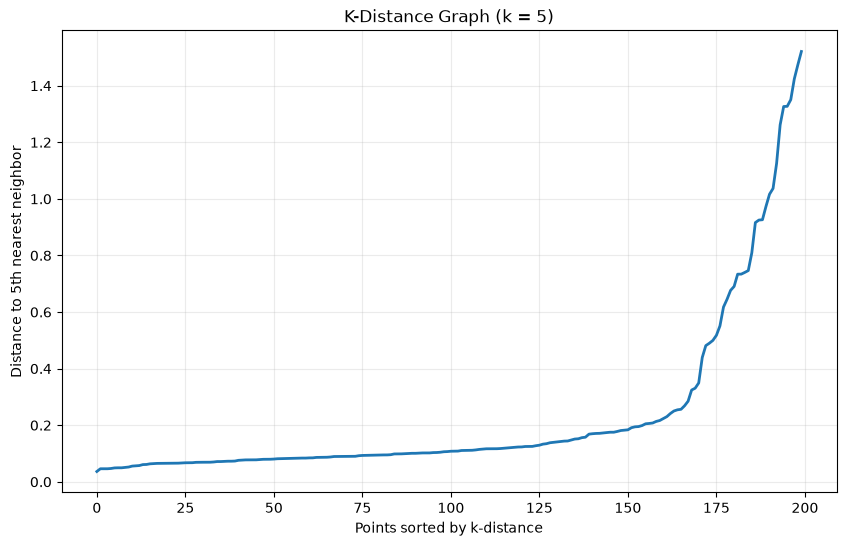

In [19]:
plt.figure(figsize=(10, 6))

plt.plot(
    k_distances_sorted,
    linewidth=2
)

plt.xlabel("Points sorted by k-distance")
plt.ylabel(f"Distance to {minPts}th nearest neighbor")
plt.title(f"K-Distance Graph (k = {minPts})")

plt.grid(alpha=0.25)

plt.show()

# Using Kneed to automatically detect the knee

In [20]:
# ============================================================
# 11. AUTOMATIC KNEE DETECTION
# ============================================================

from kneed import KneeLocator

x = np.arange(len(k_distances_sorted))

knee_locator = KneeLocator(
    x,
    k_distances_sorted,
    curve="convex",
    direction="increasing"
)

knee_index = knee_locator.knee

candidate_eps = k_distances_sorted[knee_index]

print("Knee index:", knee_index)
print("Candidate epsilon:", candidate_eps)

Knee index: 184
Candidate epsilon: 0.7466026696758491


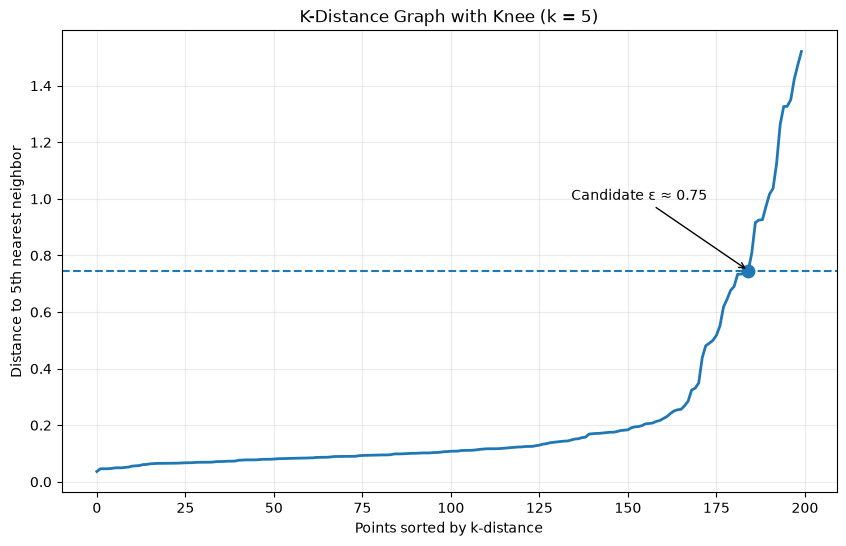

In [21]:
# ============================================================
# 12. K-DISTANCE GRAPH WITH KNEE
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    k_distances_sorted,
    linewidth=2
)

# Mark the candidate epsilon
plt.axhline(
    y=candidate_eps,
    linestyle="--",
    linewidth=1.5
)

# Mark the knee
plt.scatter(
    knee_index,
    candidate_eps,
    s=80,
    zorder=3
)

plt.annotate(
    f"Candidate ε ≈ {candidate_eps:.2f}",
    xy=(knee_index, candidate_eps),
    xytext=(knee_index - 50, candidate_eps + 0.25),
    arrowprops=dict(arrowstyle="->")
)

plt.xlabel("Points sorted by k-distance")
plt.ylabel(f"Distance to {minPts}th nearest neighbor")
plt.title(f"K-Distance Graph with Knee (k = {minPts})")

plt.grid(alpha=0.25)

plt.show()

In [23]:
dbscan = DBSCAN(
    eps=candidate_eps,
    min_samples=minPts
)

labels = dbscan.fit_predict(X_scaled)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = np.sum(labels == -1)
noise_pct = n_noise / len(labels) * 100

print(f"Number of clusters: {n_clusters}")
print(f"Number of noise points: {n_noise} ({noise_pct:.1f}%)")
print(f"Cluster sizes: {np.bincount(labels[labels >= 0])}")

Number of clusters: 2
Number of noise points: 8 (4.0%)
Cluster sizes: [101  91]


# Visualizing the Clustering

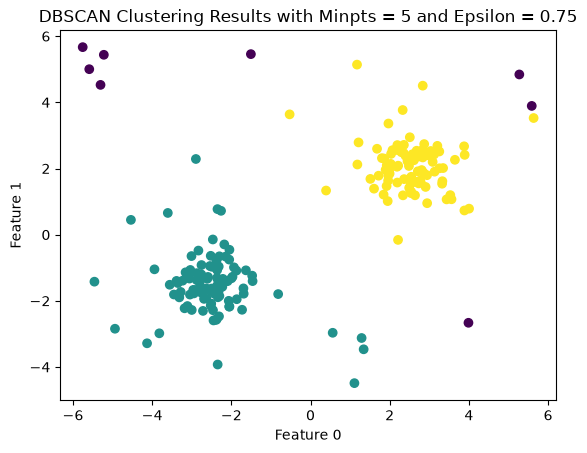

In [28]:
plt.scatter(X[:,0] , X[:,1] , c=labels)
plt.title(f"DBSCAN Clustering Results with Minpts = {minPts} and Epsilon = {candidate_eps:.2f}")
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.show()

# Due to Higher Epsilon The Clustering Algorithm is also making noisy points inside a cluster.

In [29]:
for s in [0, 1, 2]:
    kl = KneeLocator(x, k_distances_sorted, curve="convex", direction="increasing", S=s)
    print(f"S={s} -> knee_index={kl.knee}, eps={k_distances_sorted[kl.knee] if kl.knee else None}")

S=0 -> knee_index=195, eps=1.327071170221388
S=1 -> knee_index=184, eps=0.7466026696758491
S=2 -> knee_index=161, eps=0.23040311129986107


In [30]:
for eps_try in [0.6, 0.75, 0.9]:
    labels = DBSCAN(eps=eps_try, min_samples=5).fit_predict(X)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)
    print(f"eps={eps_try}: clusters={n_clusters}, noise={n_noise} ({n_noise/len(labels)*100:.1f}%)")

eps=0.6: clusters=2, noise=32 (16.0%)
eps=0.75: clusters=2, noise=30 (15.0%)
eps=0.9: clusters=2, noise=27 (13.5%)


# Choosing the Epsilon using visual inspection

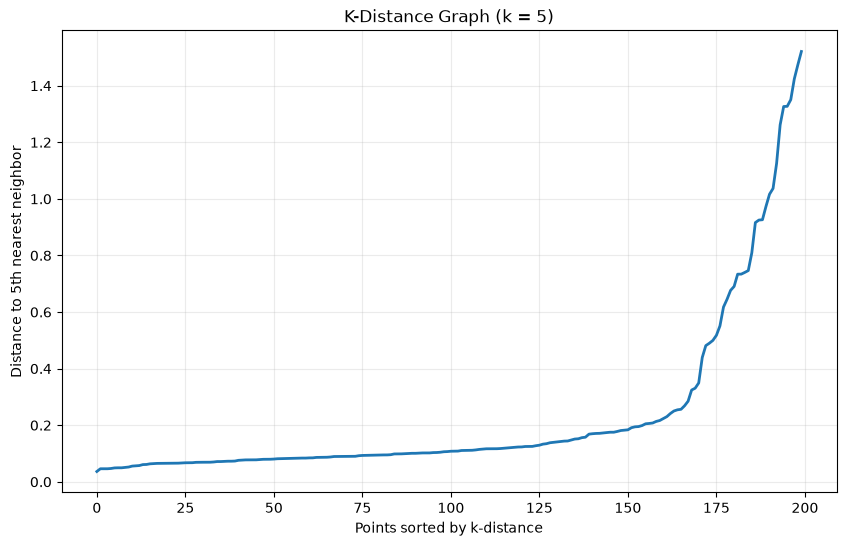

In [31]:
plt.figure(figsize=(10, 6))

plt.plot(
    k_distances_sorted,
    linewidth=2
)

plt.xlabel("Points sorted by k-distance")
plt.ylabel(f"Distance to {minPts}th nearest neighbor")
plt.title(f"K-Distance Graph (k = {minPts})")

plt.grid(alpha=0.25)

plt.show()

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    k_distances_sorted,
    linewidth=2
)

plt.xlabel("Points sorted by k-distance")
plt.ylabel(f"Distance to {minPts}th nearest neighbor")
plt.title(f"K-Distance Graph (k = {minPts})")

plt.grid(alpha=0.25)

plt.show()

# Choosing Eps as 0.36 from visual inspection

In [33]:
new_candidate_eps = 0.36

In [34]:
dbscan = DBSCAN(
    eps=new_candidate_eps,
    min_samples=minPts
)

labels = dbscan.fit_predict(X_scaled)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = np.sum(labels == -1)
noise_pct = n_noise / len(labels) * 100

print(f"Number of clusters: {n_clusters}")
print(f"Number of noise points: {n_noise} ({noise_pct:.1f}%)")
print(f"Cluster sizes: {np.bincount(labels[labels >= 0])}")

Number of clusters: 2
Number of noise points: 28 (14.0%)
Cluster sizes: [87 85]


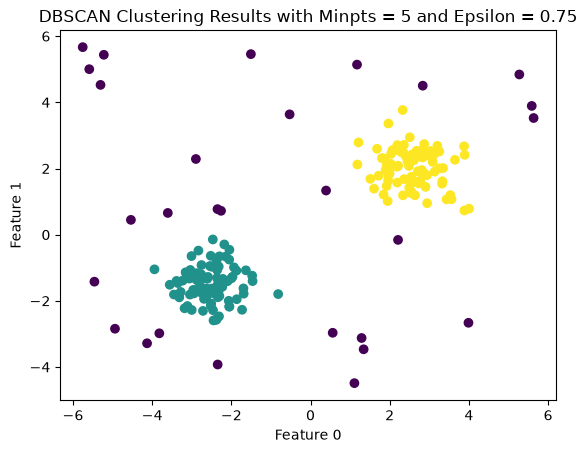

In [35]:
plt.scatter(X[:,0] , X[:,1] , c=labels)
plt.title(f"DBSCAN Clustering Results with Minpts = {minPts} and Epsilon = {candidate_eps:.2f}")
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.show()